# Lab 03-2 - Principal Component Analysis

This is a short lab that will cover the tools available in `sklearn` for principal components analysis with a focus on dimension reduction.

In [77]:
## Standard Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

Examples throughout the lab will use a large-scale personality data set obtained from the Open-Source Psychometrics Project: https://openpsychometrics.org/. These data contain several thousand responses to an online personality survey consisting of 50 statements rated on a 1 to 5 point [likert scale](https://en.wikipedia.org/wiki/Likert_scale) designed to measure the [Big 5 Personality Traits](https://en.wikipedia.org/wiki/Big_Five_personality_traits):

![](https://upload.wikimedia.org/wikipedia/commons/thumb/c/c0/Wiki-grafik_peats-de_big_five_ENG.svg/500px-Wiki-grafik_peats-de_big_five_ENG.svg.png)

In [78]:
## Big 5 data
bf = pd.read_csv("../data/big5data.csv", sep='\t')

## Split the personality questions from the demographics
bf_q = bf.drop(['race','age','engnat','gender','hand','source','country'], axis=1)
bf_demo = bf[['race','age','engnat','gender','hand','source','country']]

## Note this data has a large n relative to p (the responses to the 50 questions)
bf_q.shape

(19719, 50)

In [79]:
# Here are the first 10 rows of the demographic data:
bf_demo.head(10)

,race,age,engnat,gender,hand,source,country
0,3,53,1,1,1,1,US
1,13,46,1,2,1,1,US
2,1,14,2,2,1,1,PK
3,3,19,2,2,1,1,RO
4,11,25,2,2,1,2,US
5,13,31,1,2,1,2,US
6,5,20,1,2,1,5,US
7,4,23,2,1,1,2,IN
8,5,39,1,2,3,4,US
9,3,18,1,2,1,5,US


In [80]:
## Here are the first ten rows of the responses. Notice how the survey responses are coded in a Likert scale where: 5 = "Agree", 3 = "Neutral",  1 = "Disagree".
bf_q.head(10)

,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,...,O1,O2,O3,O4,O5,O6,O7,O8,O9,O10
0,4,2,5,2,5,1,4,3,5,1,...,4,1,3,1,5,1,4,2,5,5
1,2,2,3,3,3,3,1,5,1,5,...,3,3,3,3,2,3,3,1,3,2
2,5,1,1,4,5,1,1,5,5,1,...,4,5,5,1,5,1,5,5,5,5
3,2,5,2,4,3,4,3,4,4,5,...,4,3,5,2,4,2,5,2,5,5
4,3,1,3,3,3,1,3,1,3,5,...,3,1,1,1,3,1,3,1,5,3
5,1,5,2,4,1,3,2,4,1,5,...,4,2,1,3,3,5,5,4,5,3
6,5,1,5,1,5,1,5,4,4,1,...,3,1,5,1,4,1,4,3,3,4
7,4,3,5,3,5,1,4,3,4,3,...,3,1,5,1,4,1,5,3,2,5
8,3,1,5,1,5,1,5,2,5,3,...,3,3,5,3,5,1,5,3,4,5
9,1,4,2,5,2,4,1,4,1,5,...,4,2,5,2,4,1,4,3,4,4


What do these columns mean? Click the data's codebook [here](../data/big5_code.txt) to see what these 50 questions actually are. 

## Part 1 - Dimension Reduction

We'd expect a high degree of covariance/correlation in how participants tend to rate many of these statements. Thus, we might seek a lower dimensional representation of these data as we can retain most of information about the personalities of respondents using fewer than 50 variables. i.e. can we reduce $p=50$ to something smaller but still capture most of the information in the dataset. 

In `sklearn` the primary function used to perform principal component analysis is `PCA()`:

In [81]:
from sklearn.decomposition import PCA
pca_bfq = PCA().fit(bf_q)

Similar to the clustering functions we've worked with, we must use the `.fit()` method to perform PCA on our data. You should also note that we did not standardize these data prior to fitting because they are already on a standardized 1-5 scale. 

The `explained_variance_ratio_` attribute of our fitted PCA object stores the variance explained by each component:

In [82]:
## Variance explained by components 1-50 out of 50
var_explained = pca_bfq.explained_variance_ratio_[0:50]
var_explained

array([0.17308422, 0.10124683, 0.07403848, 0.05951973, 0.05665616,
       0.03171281, 0.02615164, 0.02158785, 0.02037202, 0.01948174,
       0.01831567, 0.01773156, 0.0166027 , 0.01608123, 0.01525932,
       0.01433665, 0.01380192, 0.01373656, 0.0130492 , 0.01278411,
       0.01252348, 0.0119322 , 0.01161321, 0.01147327, 0.01126294,
       0.01106071, 0.01068122, 0.01040463, 0.01012256, 0.00991799,
       0.00967446, 0.00931767, 0.00922926, 0.00909261, 0.00898485,
       0.00892572, 0.0088423 , 0.00857422, 0.00832548, 0.00810076,
       0.00803605, 0.00787513, 0.00758567, 0.00672724, 0.00656039,
       0.00639458, 0.00610771, 0.00548203, 0.00519131, 0.00442993])

**Question 1**: 

- **Part A**: Create a *scree plot* showing the variance explained by each component. Use this plot to identify the number of components $k$ that you think should be retained for these data.
- **Part B**: Create a plot showing the *cummulative* variance explained by each component. Ex: for $x$ = 5, y = the cummulative variance explained by the first 5 principal components. Hint: your plot should plateau at around $y$ = 1.  
- **Part C**: Looking at the plot from Part B, what is the total proportion of the variance explained by the first $k$ principal components you identified in Part A. 


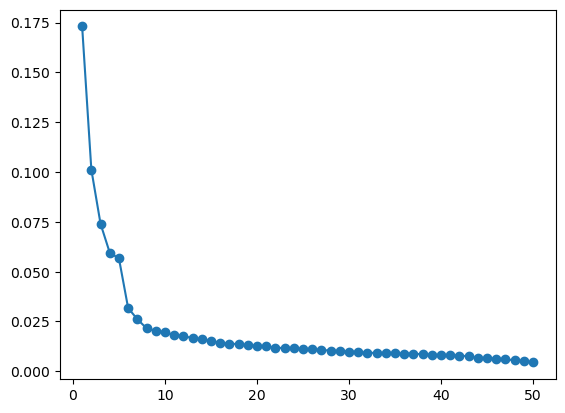

In [83]:
plt.plot(range(1, len(var_explained) + 1), var_explained, marker='o')
plt.show()

The elbow bend occurs at around 5. Therefore we should use k = 5 components.

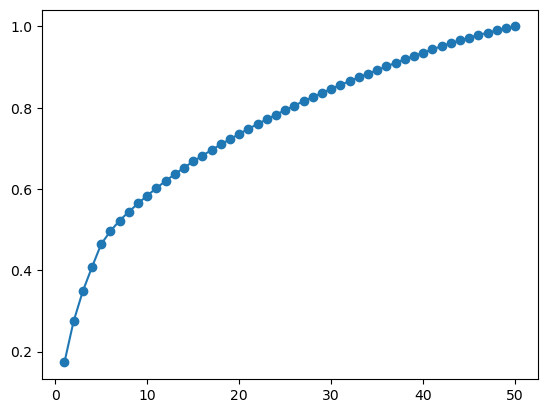

In [84]:
cumulative_var_explained = np.cumsum(var_explained)
plt.plot(range(1, len(var_explained) + 1), cumulative_var_explained, marker = 'o')
plt.show()

Total variance caused by k = 5 components is about 0.4

## Part 2 - Scores

This questionnaire was designed to measure the [Big 5 Personality Traits](https://en.wikipedia.org/wiki/Big_Five_personality_traits), so we might opt to retain only 5 principal components.

To achieve this we need to refit the PCA with the argument `n_components=5`, as the `fit_transform()` method of PCA depends upon the number of components specified when the object is created:

In [85]:
## Perform the dimension reduction
pca_bfq_5comp = PCA(n_components=5).fit_transform(bf_q)

## Verify results
pca_bfq_5comp.shape

(19719, 5)

Notice that while the original data set was 19719 x 50, the new *dimension reduced* dataset is 19719 x 5. 

The `fit_transform()` method is used to fit a PCA model with a specified number of principal components and return the lower dimensional representation of the input data utilizing those components.  You should note that `pca_bfq_5comp` contains the "scores" (ie: coordinates) of each data-point in the retained principal component dimensions.

**Question 2**: Create a scatterplot displaying scores for the first and second principal components. Color each data-point by the demographic variable `engnat` (English-speaking nationality) and briefly comment upon whether you can visually see any noticeable  differences in these scores among English-speaking nationalities compared to non-English-speaking nationalities.

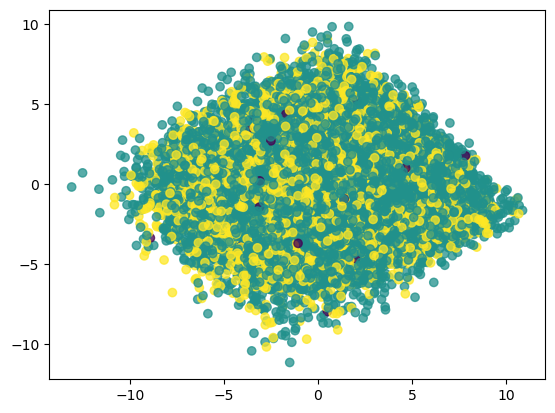

In [86]:
plt.scatter(pca_bfq_5comp[:,0],pca_bfq_5comp[:,1], c = bf_demo.engnat, alpha = 0.75)
plt.show()

There aren't any notable differences in the scores of the first two components among native English speakers and non native English speakers. 
The two groups overlap suggesting that the first two components are not strongly related to one's native language.

## Part 3 - Loadings 

In this application we're interested in assigning meaningful labels to these 5 dimensions that were derived using PCA. This can be done by inspecting the most influential loadings in each component.

In [87]:
## Loadings for a particular principal component (sorted by abs magnitude), here the first principal component PC1
PC1_loadings = pd.DataFrame({'Question': bf_q.columns, 'PC1': pca_bfq.components_[0]})
print(PC1_loadings.sort_values(by='PC1', ascending=False, key=abs).head(10))

   Question       PC1
6        E7  0.263503
2        E3  0.252589
4        E5  0.240867
9       E10 -0.223513
19      N10 -0.222202
3        E4 -0.211569
17       N8 -0.205233
18       N9 -0.197345
5        E6 -0.196707
1        E2 -0.195601


Referring to the data's codebook [here](../data/big5_code.txt), we can see that the 4 most influential statements in determining where an individual falls in the first principal component dimension are:
    
1. E7: I talk to a lot of different people at parties.
2. E3: I feel comfortable around people.
3. E5: I start conversations.
4. E10: I am quiet around strangers.

Additionally, you might notice that 7 of 10 top contributors are statements with the "E" label. This is intentional, the creators of this questionnaire designed these statements to measure extroversion, which emerges as the most prominent personality dimension in these data.

**Question 3**:

Using the most influential loadings, label each of the first five principal component dimension in `pca_bfq` as one of the Big Five personality traits: E = extroversion, O = openness, A = agreeableness, C = conscientiousness, and N = neuroticism.

In [88]:
PC2_loadings = pd.DataFrame({'Question': bf_q.columns, 'PC2': pca_bfq.components_[1]})
print(PC2_loadings.sort_values(by='PC2', ascending=False, key=abs).head(10))

   Question       PC2
17       N8  0.266317
16       N7  0.252547
15       N6  0.246212
1        E2 -0.227150
6        E7  0.217627
35       C6  0.208524
10       N1  0.207051
18       N9  0.204356
33       C4  0.203406
8        E9  0.198435


For the 2nd principal component, 5 of the question are asking about Neuroticism. We can therefore label PC2 as N

In [89]:
PC3_loadings = pd.DataFrame({'Question': bf_q.columns, 'PC3': pca_bfq.components_[2]})
print(PC3_loadings.sort_values(by='PC3', ascending=False, key=abs).head(10))

   Question       PC3
38       C9  0.271798
35       C6 -0.243957
34       C5  0.239678
25       A6  0.231302
23       A4  0.230593
31       C2 -0.228562
28       A9  0.227257
36       C7  0.223704
12       N3  0.205573
10       N1  0.198535


For the 3rd principal component, 5 of the question are asking about conscientiousness and  the top 5 loadings are for Conscientious items. We can thereofre label PC3 as C.

In [90]:
PC4_loadings = pd.DataFrame({'Question': bf_q.columns, 'PC4': pca_bfq.components_[3]})
print(PC4_loadings.sort_values(by='PC4', ascending=False, key=abs).head(10))

   Question       PC4
47       O8  0.351770
40       O1  0.322423
41       O2 -0.316664
43       O4 -0.295284
49      O10  0.238052
42       O3  0.234572
45       O6 -0.232817
48       O9  0.193937
20       A1 -0.187709
44       O5  0.180955


For the 4th principal component, the top 8 loadings are questions around openness. We can therefore label PC4 as O.

In [91]:
PC5_loadings = pd.DataFrame({'Question': bf_q.columns, 'PC5': pca_bfq.components_[4]})
print(PC5_loadings.sort_values(by='PC5', ascending=False, key=abs).head(10))

   Question       PC5
47       O8  0.235899
24       A5  0.229796
23       A4 -0.225524
20       A1  0.221208
35       C6 -0.219435
25       A6 -0.213339
22       A3  0.206820
31       C2 -0.196320
26       A7  0.196296
18       N9  0.192298


For the 5th principal component, 6 of the questions are asking about Agreeableness. The top 5 loadings also consist of Agreeable questions. We can therefore label PC5 as A

## Part 4 - On your own

The code given below loads responses to an online questionnaire  aimed at capturing "dark triad" personality traits, which are:

1. machiavellianism (a manipulative attitude)
1. narcissism (excessive self-love)
1. psychopathy (lack of empathy)

For more information you can visit this link: http://openpsychometrics.org/tests/SD3/

Like the Big 5 dataset, the statements are labeled according to which trait they were intended to measure.

**Question 4**:

- **Part A**: Perform PCA on the survey items in the dark triad data and plot the variance explained by each component. Based upon this plot, does it seem reasonable to conclude that 3 underlying factors are being measured by these questions?
- **Part B**: Using the principal component loadings, assign a label (ie: M = machiavellianism, N = narcissism, P = psychopathy) to each of the first three principal components.
- **Part C (Bonus)**: For any two countries of your choosing, create a data visualization showing the distributions of your choice of dark triad traits across the respondents from each country.

For your reference, the image below (from the appendix of Jones and Paulhus (2014) https://journals.sagepub.com/doi/full/10.1177/1073191113514105) displays the individual survey items.

In [92]:
## Code to load the data
dt = pd.read_csv("../data/dark_triad.csv", sep='\t')
dt.head(10)
dt_n =dt.drop(columns =['country'])
dt_country = dt['country']
dt_country

0        GB
1        US
2        US
3        GB
4        GB
         ..
18187    US
18188    GB
18189    US
18190    LK
18191    US
Name: country, Length: 18192, dtype: object

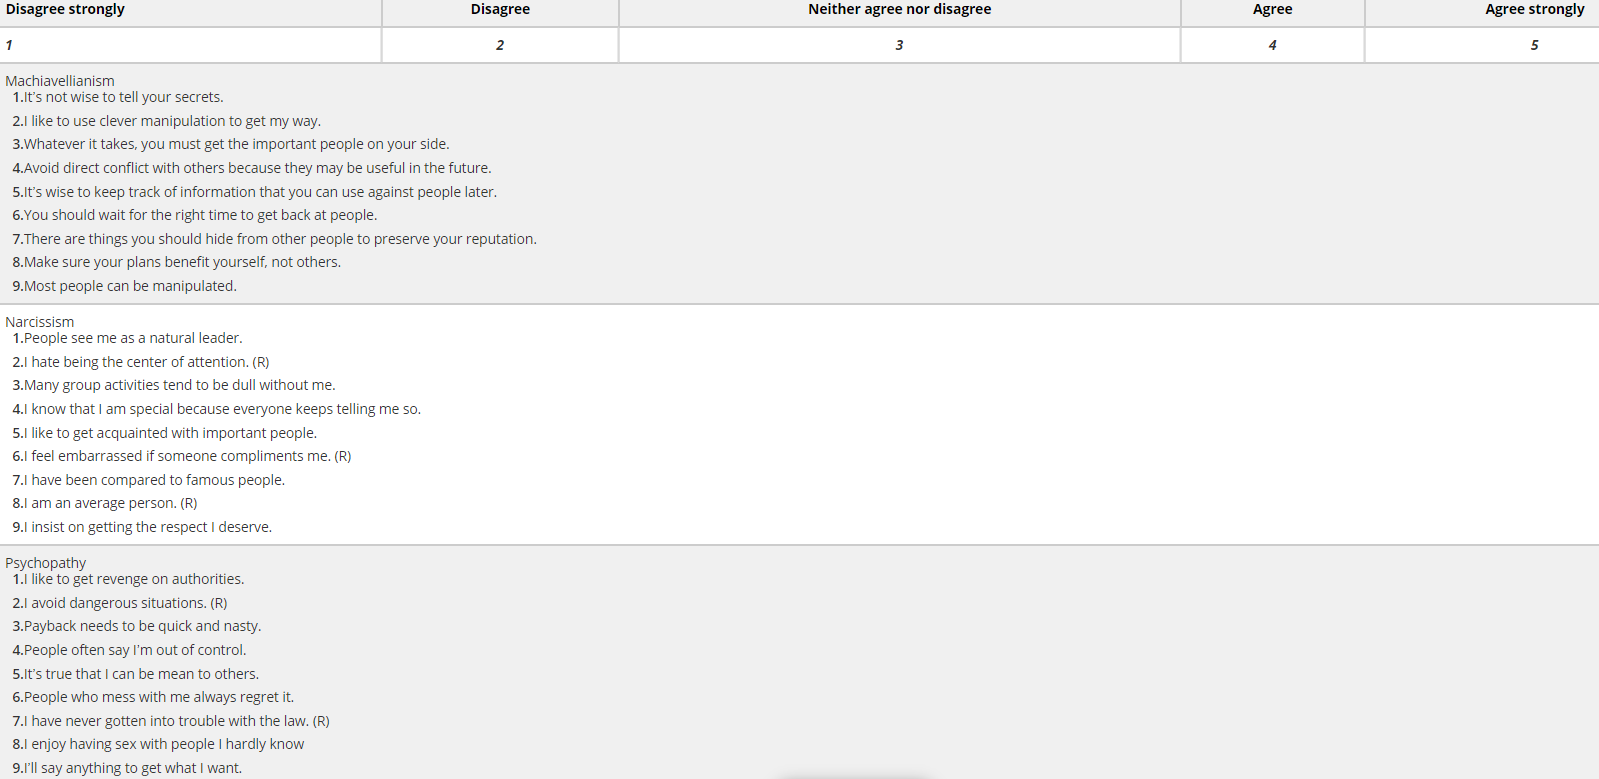

In [93]:
## Screenshot of the Dark Triad survey items 
from IPython.display import Image
Image("../images/dark.PNG")

In [94]:
pca_dt = PCA().fit(dt_n)
variance_dt = pca_dt.explained_variance_ratio_
variance_dt


array([0.31022819, 0.08233185, 0.06045615, 0.04014913, 0.03577618,
       0.03451206, 0.0327592 , 0.02963559, 0.02796167, 0.02630935,
       0.025171  , 0.02357908, 0.02209185, 0.02175851, 0.02080722,
       0.02004531, 0.01951635, 0.01878623, 0.01855232, 0.0180976 ,
       0.01716651, 0.01615759, 0.01558517, 0.01447419, 0.01331281,
       0.01255276, 0.01215271, 0.01007344])

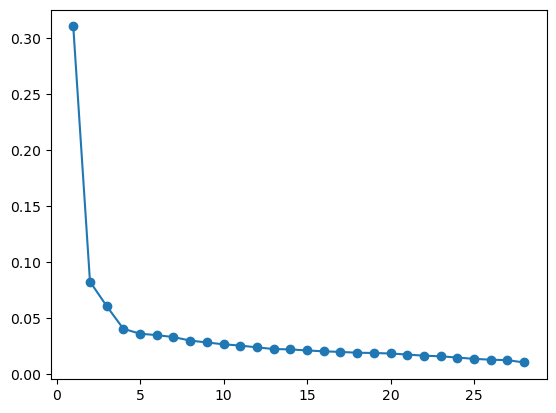

In [95]:
plt.plot(range(1, len(variance_dt) +1),variance_dt,marker='o')
plt.show()

The plot begins to elbow out at around 3. It is therefore reasonable to say that the questionnaire is measuring 3 underlying factors.

In [96]:
PC1_load = pd.DataFrame({'Question': dt_n.columns, 'PC1': pca_dt.components_[0]})
print(PC1_load.sort_values(by = 'PC1', ascending = False, key = abs).head(20))

   Question       PC1
26       P9  0.289640
4        M5  0.271216
1        M2  0.262193
23       P6  0.243620
5        M6  0.242894
18       P1  0.230108
7        M8  0.229574
2        M3  0.220951
25       P8  0.210809
20       P3  0.209725
17       N9  0.200711
13       N5  0.191672
11       N3  0.189205
22       P5  0.187590
15       N7  0.177749
12       N4  0.176004
8        M9  0.172168
16       N8 -0.169701
21       P4  0.166412
14       N6 -0.136597


Most of the top loadings in PC1 are investigating machiavellianism. We can therefore assign PC1 the label M

In [97]:
PC2_load = pd.DataFrame({'Question' : dt_n.columns, 'PC2': pca_dt.components_[1]})
print(PC2_load.sort_values(by = 'PC2',ascending = False, key = abs).head(20))

   Question       PC2
10       N2  0.420358
14       N6  0.349994
16       N8  0.262851
24       P7  0.253768
5        M6  0.247527
4        M5  0.239561
9        N1 -0.230222
15       N7 -0.230071
19       P2  0.220548
12       N4 -0.193773
3        M4  0.190444
25       P8 -0.172912
11       N3 -0.171178
20       P3  0.152323
0        M1  0.150295
6        M7  0.136565
7        M8  0.135009
1        M2  0.129840
22       P5  0.124583
18       P1  0.093155


There are significantly more Ns(7) than any other category in the 2nd principal component. This component can therefore be labelled as N (Narcissism)

In [98]:
PC3_load = pd.DataFrame({'Question': dt_n.columns, 'PC3': pca_dt.components_[2]})
print(PC3_load.sort_values(by = 'PC3', ascending = False, key = abs).head(20))

   Question       PC3
24       P7  0.616029
21       P4 -0.293871
19       P2  0.271841
25       P8 -0.258673
13       N5  0.234877
3        M4  0.231876
12       N4  0.210062
18       P1 -0.198333
2        M3  0.171532
10       N2 -0.170986
9        N1  0.170532
15       N7  0.158786
20       P3 -0.142456
14       N6 -0.135589
11       N3  0.115805
22       P5 -0.114091
17       N9  0.094844
16       N8 -0.081559
23       P6 -0.054871
1        M2  0.040653


The top 4 loadings on PC3 are asking about psychopathic tendencies. We can therefore label this principal component P (Psychopathy).

In [99]:
import seaborn as sns

In [100]:
scores = pca_dt.transform(dt_n)
dt['PC2'] = scores[:,1]

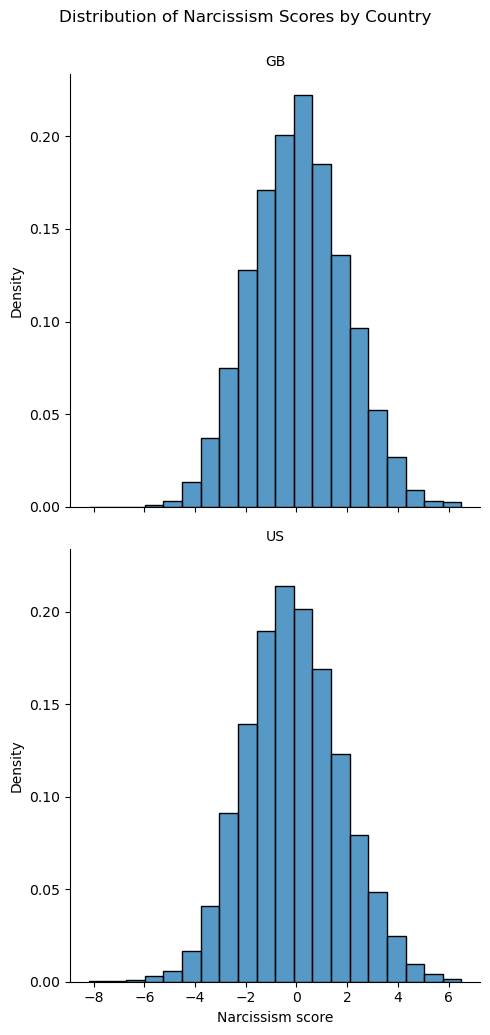

In [101]:
countries = ['US', 'GB']                      
sub = dt[dt['country'].isin(countries)]

g = sns.displot(
    data=sub, x ='PC2', row ='country',
    stat='density', common_norm=False,     
    fill =True, bins=20)
g.set_axis_labels("Narcissism score", "Density")
g.set_titles("{row_name}")
g.figure.suptitle("Distribution of Narcissism Scores by Country", y=1.03)
plt.show()